# Performance Linear Superposition

### Background
Although we have verified each point quality, we still concern that whether the influence of data is linear superposition. In other words, if samples "a" and "b" are labeled as bad data, is their combination worser than each other?

### Analysis
Since the paper[1] has verified that the *Influence Function* approximates *Leave-One-Out evaluation*, and almost equal to *Leave-One-Out evaluation* when the model is linear, we decide to leverage the approximating estimations of the influence function to investigate the linear superposition of the leave-one-out evaluation.

##### Preliminary
* Given a **dataset** $Z = \{z_1, z_2, \ldots, z_n\}$ consisting of features $\mathcal{X}$ and labels $\mathcal{Y}$, each sample denotes $z_i=(x_i,y_i) \in \mathcal{X}\times\mathcal{Y}$.
* Given a **model** parameterized by $\theta \in \Theta$, which is updated by minimizing a loss function $\mathcal{L}$, $i.e.$,
$$\hat{\theta} := \mathop{\arg\min}_{\theta\in\Theta} \frac{1}{n} \sum_{i=1}^n \mathcal{L}(z_i,\theta).$$
* We simplify the annotation of empirical risk by,
$$R(\theta) := \frac{1}{n} \sum_{i=1}^n \mathcal{L}(z_i,\theta).$$
* To satisfy the following analysis, we assume $R(\theta)$ is convex and twice-differentiable, satisfied by linear model parameters and most common loss functions ($e.g.$, Cross-Entropy and MSE). Therefore, exist Hessian matrix of loss function, $i.e.$,
$$H_{\theta} := \nabla^2 R(\theta) = \nabla^2 \left[\frac{1}{n} \sum_{i=1}^n \mathcal{L}(z_i,\theta)\right] = \frac{1}{n} \sum_{i=1}^n \nabla_{\theta}^2\mathcal{L}(z_i,\theta).$$
* In convenient, we use $Z_{-S}$ to denote the dataset which leaves a subset $S \subseteq Z$ out, and $\theta_{-S}$ denotes the model parameters updated by $Z_{-S}$, $i.e.$,
$$\hat{\theta}_{-S} := \mathop{\arg\min}_{\theta\in\Theta} \frac{1}{n} \sum_{z_i \in Z_{-S}} \mathcal{L}(z_i,\theta).$$
* Therefore, the influence of removing subset ${S}$ from $Z$ on model parameters denotes as $\hat{\theta}_{-S} - \hat{\theta}$.
* According to the definition in [1], we extend influence of single sample to influence of subset $S$ on the loss of at a test sample $s_{test}$ as,
$$\mathcal{I}(S,s_{test}) := \left.\dfrac{d\mathcal{L}(s_{test}, \hat{\theta}_{\epsilon,S})}{d\epsilon}\right|_{\epsilon=0}. \tag{1}$$
* where we assume the model parameters is updated with a small step $\epsilon$ on $s$,
$$\hat{\theta}_{\epsilon,S} := \mathop{\arg\min}_{\theta\in\Theta} R(\theta) + \epsilon \mathcal{L}(S,\theta). \tag{2}$$
>Re.: the influence of removing subset $S$ on the loss of $s_{test}$ is $-\mathcal{I}(S,s_{test})$, because removing $S$ is the same as updating the parameters by $\epsilon=−\frac{1}{n}$ on $S$.

##### Assume $\|S\| = 1$
In this case, subset $S$ only contains a single sample denoted $s \in Z$. Eq (1) can be customized as,
$$\hat{\theta}_{\epsilon,s} := \mathop{\arg\min}_{\theta\in\Theta} R(\theta) + \epsilon \mathcal{L}(s,\theta). \tag{1.1}$$

The following process is derived from [2]. Because $\hat{\theta}_{\epsilon,s}$ is a minimizer of eq (1.1), we examine the first order optimality conditions of it,
$$0 = \nabla R(\hat{\theta}_{\epsilon,s}) + \epsilon\nabla\mathcal{L}(s,\hat{\theta}_{\epsilon,s}). \tag{1.2}$$
>Re.: as we assumed $R(\theta)$ is convex, the derivative at the extreme point is 0. We omit the subscript of gradient for brevity.

Since $\hat{\theta}_{\epsilon,s} \rightarrow \hat{\theta}$ as $\epsilon \rightarrow 0$, we perform a Taylor expansion for the $\hat{\theta}_{\epsilon,s}$ around $\hat{\theta}$ of eq (1.2) right-hand side,
$$0 \approx \left[ \nabla R(\hat{\theta}) + \epsilon\nabla\mathcal{L}(s,\hat{\theta}) \right] + \left[ \nabla^2 R(\hat{\theta}) + \epsilon\nabla^2\mathcal{L}(s,\hat{\theta}) \right](\hat{\theta}_{\epsilon,s} - \hat{\theta}) + o(\hat{\theta}_{\epsilon,s} - \hat{\theta}).$$

By omitting the Peano remainder, the influence is denoted as,
$$\Delta_{\epsilon} := \hat{\theta}_{\epsilon,s} - \hat{\theta} = -\left[ \nabla^2 R(\hat{\theta}) + \epsilon\nabla^2\mathcal{L}(s,\hat{\theta}) \right]^{-1} \left[ \nabla R(\hat{\theta}) + \epsilon\nabla\mathcal{L}(s,\hat{\theta}) \right].$$

Since $\hat{\theta}$ minimzes $R(\theta)$, we have $\nabla R(\hat{\theta}) = 0$. Keeping only
$O(\epsilon)$ terms, we have,
$$\Delta_{\epsilon} \approx - \nabla^2 R(\hat{\theta})^{-1} \nabla\mathcal{L}(s,\hat{\theta}) \epsilon = -H_{\hat{\theta}}^{-1} \nabla\mathcal{L}(s,\hat{\theta}) \epsilon \tag{1.3}.$$

By applying the chain rule to eq (2), the influence of sample $s$ on the loss test sample $s_{test}$ is,
$$\mathcal{I}(s, s_{test}) = \left.\dfrac{d\mathcal{L}(s_{test}, \hat{\theta}_{\epsilon,s})}{d\epsilon}\right|_{\epsilon=0} = \nabla_{\theta} \mathcal{L}(s_{test}, \hat{\theta})^{T} \left.\dfrac{d\hat{\theta}_{\epsilon,s}} {d\epsilon}\right|_{\epsilon=0}. \tag{1.4}$$

Since the second term of $\Delta_{\epsilon}$ is irrelative to $\epsilon$, we have,
$$\frac{d\Delta_{\epsilon}}{d\epsilon} = \frac{d\hat{\theta}_{\epsilon,s}}{d\epsilon}. \tag{1.5}$$

By combining eq (1.5) and eq (1.3) to eq (1.4), we obtain the final result of the influence of sample $s$ on the loss test sample $s_{test}$,
$$\begin{aligned}
\mathcal{I}(s, s_{test}) & = \nabla_{\theta} \mathcal{L}(s_{test}, \hat{\theta})^{T} \left.\dfrac{d\hat{\theta}_{\epsilon,s}} {d\epsilon}\right|_{\epsilon=0} \\
& = \nabla_{\theta} \mathcal{L}(s_{test}, \hat{\theta})^{T} \left.\frac{d\Delta_{\epsilon}}{d\epsilon}\right|_{\epsilon=0}\\
& = -\nabla_{\theta} \mathcal{L}(s_{test}, \hat{\theta})^{T} H_{\hat{\theta}}^{-1} \nabla_{\theta}\mathcal{L}(s,\hat{\theta}).
\end{aligned}$$

##### Assume $\|S\| = 2$
In this case, subset $S$ contains two samples $s_1, s_2 \in Z$. Eq (1) can be customized as,
$$\hat{\theta}_{\epsilon,S} := \mathop{\arg\min}_{\theta\in\Theta} R(\theta) + \epsilon \mathcal{L}(S,\theta). \tag{2.1}$$
Since $\epsilon$ could be any small number, we can replace $\epsilon$ with $\epsilon_2=\epsilon/2$ without loss of generality. Moreover, the loss of a dataset is equal (in proportion) to the linear combination of each sample's loss. Therefore, Eq (2.1) is equal to,
$$\hat{\theta}_{\epsilon,S} = \mathop{\arg\min}_{\theta\in\Theta} R(\theta) + \epsilon_2 \mathcal{L}(s_1,\theta) + \epsilon_2 \mathcal{L}(s_2,\theta). \tag{2.2}$$

Because $\hat{\theta}_{\epsilon,S}$ is a minimizer of eq (2.2), we examine the first order optimality conditions of it,
$$0 = \nabla R(\hat{\theta}_{\epsilon,S}) +\epsilon_2 \nabla \mathcal{L}(s_1,\hat{\theta}_{\epsilon,S}) + \epsilon_2 \nabla \mathcal{L}(s_2,\hat{\theta}_{\epsilon,S}). \tag{2.3}$$

Since $\hat{\theta}_{\epsilon,S} \rightarrow \hat{\theta}$ as $\epsilon_2 \rightarrow 0$, we perform a Taylor expansion for the $\hat{\theta}_{\epsilon,S}$ around $\hat{\theta}$ of eq (2.3) right-hand side,
$$0 \approx \left[ \nabla R(\hat{\theta}) + \epsilon_2 \nabla\mathcal{L}(s_1,\hat{\theta}) + \epsilon_2 \nabla\mathcal{L}(s_2,\hat{\theta}) \right] + \left[ \nabla^2 R(\hat{\theta}) + \epsilon_2 \nabla^2\mathcal{L}(s_1,\hat{\theta}) + \epsilon_2 \nabla^2\mathcal{L}(s_2,\hat{\theta}) \right](\hat{\theta}_{\epsilon,S} - \hat{\theta}) + o(\hat{\theta}_{\epsilon,S} - \hat{\theta}). \tag{2.4}$$

By omitting the Peano remainder, the influence is denoted as,
$$\Delta_{\epsilon} := \hat{\theta}_{\epsilon,S} - \hat{\theta} = -\left[ \nabla^2 R(\hat{\theta}) + \epsilon_2 \nabla^2 \mathcal{L}(s_1,\hat{\theta}) + \epsilon_2 \nabla^2 \mathcal{L}(s_2,\hat{\theta}) \right]^{-1} \left[ \nabla R(\hat{\theta}) + \epsilon_2 \nabla \mathcal{L}(s_1,\hat{\theta}) + \epsilon_2 \nabla \mathcal{L}(s_2,\hat{\theta}) \right].$$

Since $\hat{\theta}$ minimzes $R(\theta)$, we have $\nabla R(\hat{\theta}) = 0$. Keeping only
$O(\epsilon)$ terms, we have,
$$\Delta_{\epsilon} \approx - \nabla^2 R(\hat{\theta})^{-1} [\nabla\mathcal{L}(s_1,\hat{\theta}) + \nabla\mathcal{L}(s_2,\hat{\theta})] \epsilon_2 = -H_{\hat{\theta}}^{-1} [\nabla\mathcal{L}(s_1,\hat{\theta}) + \nabla\mathcal{L}(s_2,\hat{\theta})] \epsilon_2 \tag{2.5}.$$

Following the same ideas of eq (1.4) and eq (1.5), we verify the linear superposition of influence of subset consisting of two samples on the loss test sample $s_{test}$,
$$\mathcal{I}(S, s_{test}) = - \nabla_{\theta} \mathcal{L}(s_{test}, \hat{\theta})^{T} H_{\hat{\theta}}^{-1} [\nabla_{\theta}\mathcal{L}(s_1,\hat{\theta}) + \nabla_{\theta}\mathcal{L}(s_2,\hat{\theta})] = \mathcal{I}(s_1, s_{test}) + \mathcal{I}(s_2, s_{test}).$$

##### Assume $\|S\| = m$
In this case, subset $S$ contains $m$ samples $s_1, s_2, \ldots, s_m \in Z$. Without loss of generality, we can derive the $\hat{\theta}_{\epsilon,S}$ by denoting $\epsilon_m=\epsilon/m$ similar to eq (2.2),
$$\hat{\theta}_{\epsilon,S} = \mathop{\arg\min}_{\theta\in\Theta} R(\theta) + \epsilon_m \sum_{i=1}^m \mathcal{L}(s_i,\theta).$$
> Re.: In practice, usually have $m \ll n$. I used to take the relationship between $m$ and $n$ as one of the assumptions, but it is unnecessary. By letting $\epsilon_m=\epsilon/m$, the following results always hold for any big $m$.

According to the property of derivative on the extreme point, we have,
$$0 = \nabla R(\hat{\theta}_{\epsilon,S}) +\epsilon_m \sum_{i=1}^m \nabla \mathcal{L}(s_i,\hat{\theta}_{\epsilon,S}).$$
Again, we perform a Taylor expansion for the $\hat{\theta}_{\epsilon,S}$ around $\hat{\theta}$ and omit the Peano remainder, the influence is denoted as,
$$\Delta_{\epsilon} := \hat{\theta}_{\epsilon,S} - \hat{\theta} = -\left[ \nabla^2 R(\hat{\theta}) + \epsilon_m \sum_{i=1}^m \nabla^2 \mathcal{L}(s_i,\hat{\theta})) \right]^{-1} \left[ \nabla R(\hat{\theta}) + \epsilon_m \sum_{i=1}^m \nabla \mathcal{L}(s_i,\hat{\theta}) \right].$$
Following the same step as eq (2.5), we finally have,
$$\mathcal{I}(S, s_{test}) = - \nabla_{\theta} \mathcal{L}(s_{test}, \hat{\theta})^{T} H_{\hat{\theta}}^{-1} \sum_{i=1}^m\nabla_{\theta}\mathcal{L}(s_i,\hat{\theta}) = \sum_{i=1}^m \mathcal{I}(s_i, s_{test}).$$
It demonstrates that the influence of a subset on a test point is equal to the linear superposition of the influence of each sample in the subset.

### Conclusion
Overall, the condition for linear superposition of sample influence is simple, only requiring a convex, twice-differential, and linear superposition empirical risk function $R(\theta)$.

### Reference
1. ICML2017 - Understanding Black-box Predictions via Influence Functions
2. Technometrics1977 - Detection of Influential Observation in Linear Regression

In [1]:
import os
import sys
from functools import partial

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, Subset, TensorDataset
from transformers import logging

os.chdir('..')
sys.path.append('.')
import configs
from models.resnet import *
from models.vit import *
from utils.dataset import load_cv_dataset
from utils.path import set_eval_path
from utils.nn import set_seed
from utils.nn.classifier import train, test
from utils.nn.io import load_embedding


set_seed(0)
device = torch.device('cuda:1')
logging.set_verbosity_error()

In [2]:
net = 'vit'
dataset = 'cifar10'
embed_dataset = 'imagenet21k'

if net in ['vit', 'mae', 'beit']:
    param = getattr(configs, f'{net}_{embed_dataset}_params') 
else:
    param = getattr(configs, f'{net}_{dataset}_params')
trainset = load_cv_dataset(dataset, train=True, augment=False, resize=param['input_size'])
testset  = load_cv_dataset(dataset, train=False, augment=False, resize=param['input_size'])
classes  = trainset.classes

In [3]:
date = '666666-6666'
bs   = 128

embed = load_embedding(model=net, dataset=embed_dataset, algo='pt',date=date, epoch=-1, param=param).to(device)

dataloader = DataLoader(dataset=trainset, batch_size=bs, shuffle=False)
with torch.no_grad():
    x = torch.cat([embed(x.to(device)).cpu() for x, _ in dataloader], dim=0)
    y = torch.Tensor(dataset.targets).long() if hasattr(dataset, 'targets') else torch.cat([y for _, y in dataloader], dim=0).long()
trainset = TensorDataset(x, y)

dataloader = DataLoader(dataset=testset, batch_size=bs, shuffle=False)
with torch.no_grad():
    x = torch.cat([embed(x.to(device)).cpu() for x, _ in dataloader], dim=0)
    y = torch.Tensor(testset.targets).long() if hasattr(testset, 'targets') else torch.cat([y for _, y in dataloader], dim=0).long()
testset = TensorDataset(x, y)

embed.cpu()
del embed

In [4]:
date   = '230830-1225'
iter_  = 0
del_n  = [0, 10, 20, 30, 40, 50]
repeat = 10

filepath = set_eval_path(dataset=dataset, date=date)
results  = pd.read_csv(filepath)[f'iter:{iter_}-true']
bad_data = results[results == 1].index.values
bad_data = np.array([np.random.choice(bad_data, max(del_n), replace=False) for _ in range(repeat)])

In [5]:
if net in ['vit', 'mae', 'beit']:
    model_func = partial(nn.Linear, in_features=x.shape[-1], out_features=len(classes))
else:
    partial(eval(net), **param)

In [6]:
epoch     = 10
lr        = 1e-3
bs        = 128
alpha     = 0.95
criterion = nn.CrossEntropyLoss()

testloader = DataLoader(testset, batch_size=bs, shuffle=False)

losses = np.zeros((len(del_n), repeat))
for i, n in enumerate(del_n):
    for r in range(repeat):
        # set subset.
        if n == 0:
            index = list(range(len(trainset)))
        else:
            index = list(set(range(len(trainset))) - set(bad_data[r,:n]))
        trainloader = DataLoader(Subset(trainset, index), batch_size=bs, shuffle=True)
        
        # set model.
        model = model_func().to(device)
        optim = torch.optim.Adam(model.parameters(), lr=lr)
        
        loss = 0
        for _ in range(epoch):
            train(model, trainloader, optim, criterion)
            loss_, _ = test(model, testloader, criterion)
            loss = alpha * loss_ + (1 - alpha) * loss
        losses[i, r] = loss

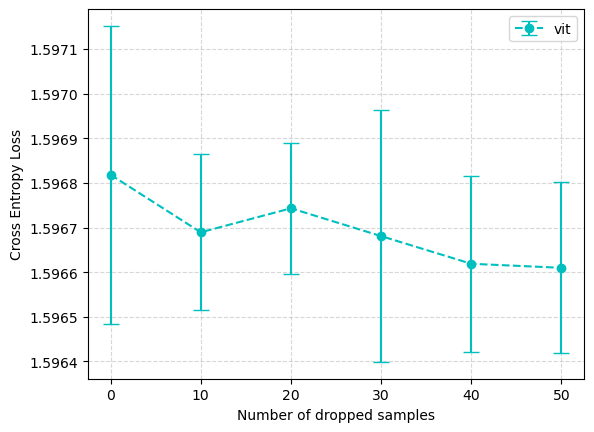

In [7]:
fig, ax = plt.subplots(1,1, dpi=100)
ax.grid(alpha=0.5, linestyle='--')
ax.errorbar(del_n, losses.mean(axis=1), yerr=losses.std(axis=1), fmt='co--', capsize=6, label=net)
ax.set_xlabel('Number of Dropped Samples')
ax.set_ylabel('Cross Entropy Loss')
ax.legend()
fig.show()